
=== PrimeVul | Within-Project: linux | ADASYN ===
    Device: mps

[1/6] Loading embeddings...
      Train (linux): (43212, 768)  vuln=1002  benign=42210
      Test  (linux): (4140, 768)  vuln=70  benign=4070
      Train imbalance ratio: 0.0232

[2/6] Normalising embeddings...

[3/6] Applying ADASYN...
      Before ADASYN — benign: 42210 | vuln: 1002 | ratio: 42.13
      After  ADASYN — benign: 42210 | vuln: 42441 | ratio: 0.99

[4/6] Computing class weights...
      Class weights (post-ADASYN): {0: 1.0027363184079603, 1: 0.9972785749628896}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6155
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.5764
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.5283
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.4694
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.4201
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.3849
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.3569
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.3321
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.3136
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.2948
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.2818
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.2632
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.2482
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.2344
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.2293
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.2102
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6065
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.5773
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.5305
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.4815
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.4338
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.3975
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.3673
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.3453
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.3265
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.3130
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.2950
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.2803
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.2716
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.2588
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.2400
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.2310
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.5991
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.5584
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.4991
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.4366
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.3878
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.3565
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.3307
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.3090
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.2904
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.2723
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.2551
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.2409
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.2251
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.2124
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.2004
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.1900
 

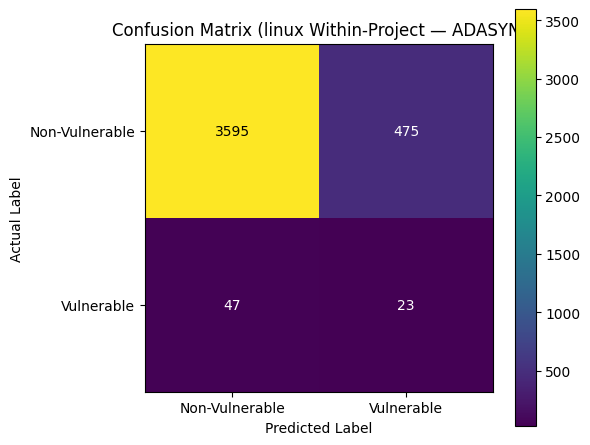

In [1]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on linux (train split) -> Test on linux (test split)
ADASYN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "linux"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/adasyn"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the ADASYN-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — ADASYN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | ADASYN ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to linux only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply ADASYN on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying ADASYN...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before ADASYN — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    # ADASYN may produce slightly variable sample counts across runs
    # due to its density-based adaptive sampling strategy
    adasyn = ADASYN(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # ADASYN can fail when minority class is extremely small
        # (fewer samples than n_neighbors). Fall back with n_neighbors=1.
        print(f"      ADASYN default failed ({e}). Retrying with n_neighbors=1...")
        adasyn = ADASYN(random_state=SEED, n_neighbors=1)
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  ADASYN — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-ADASYN): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "adasyn_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_adasyn" : int(len(train_lbl)),
        "n_train_after_adasyn"  : int(len(train_lbl_res)),
        "n_vuln_before_adasyn"  : n_pos_before,
        "n_benign_before_adasyn": n_neg_before,
        "n_vuln_after_adasyn"   : n_pos_after,
        "n_benign_after_adasyn" : n_neg_after,
        "n_test_samples"        : int(len(test_lbl)),
        "n_vuln_test"           : int(test_lbl.sum()),
        "class_weights"         : class_weights,
        "accuracy"              : round(float(accuracy),  4),
        "precision"             : round(float(precision), 4),
        "recall"                : round(float(recall),    4),
        "f1"                    : round(float(f1),        4),
        "auc"                   : round(float(auc),       4),
        "g_mean"                : round(float(g_mean),    4),
        "pf"                    : round(float(pf),        4),
        "confusion_matrix"      : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"adasyn_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_adasyn_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: tensorflow | ADASYN ===
    Device: mps

[1/6] Loading embeddings...
      Train (tensorflow): (1089, 768)  vuln=76  benign=1013
      Test  (tensorflow): (1313, 768)  vuln=91  benign=1222
      Train imbalance ratio: 0.0698

[2/6] Normalising embeddings...

[3/6] Applying ADASYN...
      Before ADASYN — benign: 1013 | vuln: 76 | ratio: 13.33
      After  ADASYN — benign: 1013 | vuln: 1005 | ratio: 1.01

[4/6] Computing class weights...
      Class weights (post-ADASYN): {0: 0.9960513326752222, 1: 1.0039800995024875}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6923
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6907
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6891
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6875
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6858
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6839
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6819
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6797
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6769
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6735
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6697
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6655
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6608
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6556
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6498
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6434
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.7015
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6996
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6981
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6966
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6952
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6939
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6922
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6901
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6878
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6851
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6824
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6796
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6760
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6717
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6666
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6609
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6928
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6917
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6906
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6891
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6872
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6852
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6829
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6800
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6766
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6721
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6669
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6602
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6526
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6440
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6341
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6234
 

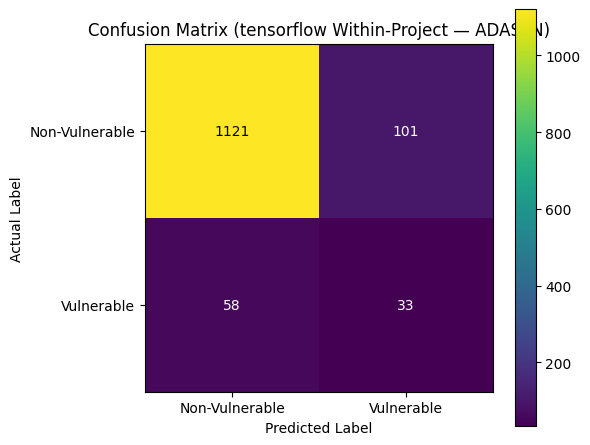

In [2]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on tensorflow (train split) -> Test on tensorflow (test split)
ADASYN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "tensorflow"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/adasyn"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the ADASYN-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — ADASYN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | ADASYN ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to tensorflow only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply ADASYN on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying ADASYN...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before ADASYN — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    # ADASYN may produce slightly variable sample counts across runs
    # due to its density-based adaptive sampling strategy
    adasyn = ADASYN(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # ADASYN can fail when minority class is extremely small
        # (fewer samples than n_neighbors). Fall back with n_neighbors=1.
        print(f"      ADASYN default failed ({e}). Retrying with n_neighbors=1...")
        adasyn = ADASYN(random_state=SEED, n_neighbors=1)
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  ADASYN — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-ADASYN): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "adasyn_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_adasyn" : int(len(train_lbl)),
        "n_train_after_adasyn"  : int(len(train_lbl_res)),
        "n_vuln_before_adasyn"  : n_pos_before,
        "n_benign_before_adasyn": n_neg_before,
        "n_vuln_after_adasyn"   : n_pos_after,
        "n_benign_after_adasyn" : n_neg_after,
        "n_test_samples"        : int(len(test_lbl)),
        "n_vuln_test"           : int(test_lbl.sum()),
        "class_weights"         : class_weights,
        "accuracy"              : round(float(accuracy),  4),
        "precision"             : round(float(precision), 4),
        "recall"                : round(float(recall),    4),
        "f1"                    : round(float(f1),        4),
        "auc"                   : round(float(auc),       4),
        "g_mean"                : round(float(g_mean),    4),
        "pf"                    : round(float(pf),        4),
        "confusion_matrix"      : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"adasyn_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_adasyn_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: vim | ADASYN ===
    Device: mps

[1/6] Loading embeddings...
      Train (vim): (951, 768)  vuln=38  benign=913
      Test  (vim): (1669, 768)  vuln=61  benign=1608
      Train imbalance ratio: 0.0400

[2/6] Normalising embeddings...

[3/6] Applying ADASYN...
      Before ADASYN — benign: 913 | vuln: 38 | ratio: 24.03
      After  ADASYN — benign: 913 | vuln: 908 | ratio: 1.01

[4/6] Computing class weights...
      Class weights (post-ADASYN): {0: 0.9972617743702081, 1: 1.0027533039647578}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6913
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6904
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6895
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6887
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6879
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6870
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6860
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6847
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6831
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6812
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6790
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6764
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6737
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6707
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6675
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6642
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6963
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6954
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6945
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6935
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6925
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6915
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6905
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6894
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6882
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6868
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6852
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6833
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6810
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6782
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6757
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6727
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6929
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6922
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6916
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6908
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6897
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6884
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6869
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6852
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6831
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6808
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6779
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6747
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6707
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6663
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6615
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6564
 

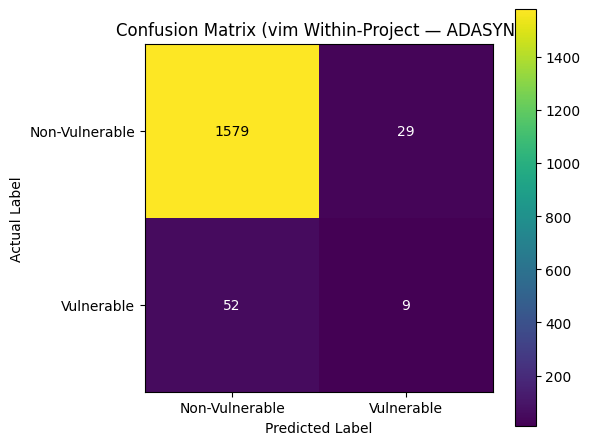

In [3]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on vim (train split) -> Test on vim (test split)
ADASYN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "vim"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/adasyn"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the ADASYN-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — ADASYN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | ADASYN ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to vim only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply ADASYN on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying ADASYN...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before ADASYN — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    # ADASYN may produce slightly variable sample counts across runs
    # due to its density-based adaptive sampling strategy
    adasyn = ADASYN(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # ADASYN can fail when minority class is extremely small
        # (fewer samples than n_neighbors). Fall back with n_neighbors=1.
        print(f"      ADASYN default failed ({e}). Retrying with n_neighbors=1...")
        adasyn = ADASYN(random_state=SEED, n_neighbors=1)
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  ADASYN — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-ADASYN): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "adasyn_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_adasyn" : int(len(train_lbl)),
        "n_train_after_adasyn"  : int(len(train_lbl_res)),
        "n_vuln_before_adasyn"  : n_pos_before,
        "n_benign_before_adasyn": n_neg_before,
        "n_vuln_after_adasyn"   : n_pos_after,
        "n_benign_after_adasyn" : n_neg_after,
        "n_test_samples"        : int(len(test_lbl)),
        "n_vuln_test"           : int(test_lbl.sum()),
        "class_weights"         : class_weights,
        "accuracy"              : round(float(accuracy),  4),
        "precision"             : round(float(precision), 4),
        "recall"                : round(float(recall),    4),
        "f1"                    : round(float(f1),        4),
        "auc"                   : round(float(auc),       4),
        "g_mean"                : round(float(g_mean),    4),
        "pf"                    : round(float(pf),        4),
        "confusion_matrix"      : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"adasyn_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_adasyn_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: gpac | ADASYN ===
    Device: mps

[1/6] Loading embeddings...
      Train (gpac): (2775, 768)  vuln=32  benign=2743
      Test  (gpac): (1884, 768)  vuln=18  benign=1866
      Train imbalance ratio: 0.0115

[2/6] Normalising embeddings...

[3/6] Applying ADASYN...
      Before ADASYN — benign: 2743 | vuln: 32 | ratio: 85.72
      After  ADASYN — benign: 2743 | vuln: 2732 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-ADASYN): {0: 0.9979948960991615, 1: 1.0020131771595902}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6876
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6822
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6750
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6649
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6507
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6321
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6086
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.5816
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.5532
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.5264
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.5025
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.4814
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.4645
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.4517
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.4421
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.4349
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6925
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6887
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6828
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6753
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6640
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6466
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6225
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.5928
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.5609
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.5291
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.4997
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.4753
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.4582
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.4456
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.4373
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.4305
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6905
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6855
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6777
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6631
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6389
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6034
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.5633
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.5255
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.4943
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.4718
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.4562
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.4447
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.4346
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.4253
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.4118
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.3929
 

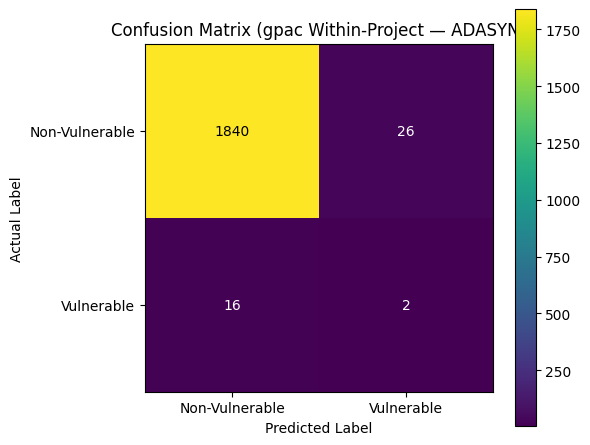

In [4]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on gpac (train split) -> Test on gpac (test split)
ADASYN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "gpac"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/adasyn"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the ADASYN-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — ADASYN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | ADASYN ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to gpac only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply ADASYN on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying ADASYN...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before ADASYN — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    # ADASYN may produce slightly variable sample counts across runs
    # due to its density-based adaptive sampling strategy
    adasyn = ADASYN(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # ADASYN can fail when minority class is extremely small
        # (fewer samples than n_neighbors). Fall back with n_neighbors=1.
        print(f"      ADASYN default failed ({e}). Retrying with n_neighbors=1...")
        adasyn = ADASYN(random_state=SEED, n_neighbors=1)
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  ADASYN — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-ADASYN): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "adasyn_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_adasyn" : int(len(train_lbl)),
        "n_train_after_adasyn"  : int(len(train_lbl_res)),
        "n_vuln_before_adasyn"  : n_pos_before,
        "n_benign_before_adasyn": n_neg_before,
        "n_vuln_after_adasyn"   : n_pos_after,
        "n_benign_after_adasyn" : n_neg_after,
        "n_test_samples"        : int(len(test_lbl)),
        "n_vuln_test"           : int(test_lbl.sum()),
        "class_weights"         : class_weights,
        "accuracy"              : round(float(accuracy),  4),
        "precision"             : round(float(precision), 4),
        "recall"                : round(float(recall),    4),
        "f1"                    : round(float(f1),        4),
        "auc"                   : round(float(auc),       4),
        "g_mean"                : round(float(g_mean),    4),
        "pf"                    : round(float(pf),        4),
        "confusion_matrix"      : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"adasyn_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_adasyn_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: FreeRDP | ADASYN ===
    Device: mps

[1/6] Loading embeddings...
      Train (FreeRDP): (872, 768)  vuln=23  benign=849
      Test  (FreeRDP): (26, 768)  vuln=1  benign=25
      Train imbalance ratio: 0.0264

[2/6] Normalising embeddings...

[3/6] Applying ADASYN...
      Before ADASYN — benign: 849 | vuln: 23 | ratio: 36.91
      After  ADASYN — benign: 849 | vuln: 849 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-ADASYN): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6899
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6887
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6877
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6868
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6858
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6847
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6835
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6820
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6805
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6788
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6768
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6746
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6722
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6696
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6665
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6631
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6908
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6898
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6888
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6878
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6867
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6856
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6846
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6835
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6823
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6810
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6796
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6779
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6762
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6741
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6716
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6691
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6931
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6925
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6918
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6910
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6900
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6886
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6870
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6852
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6831
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6808
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6779
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6747
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6709
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6664
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6614
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6555
 

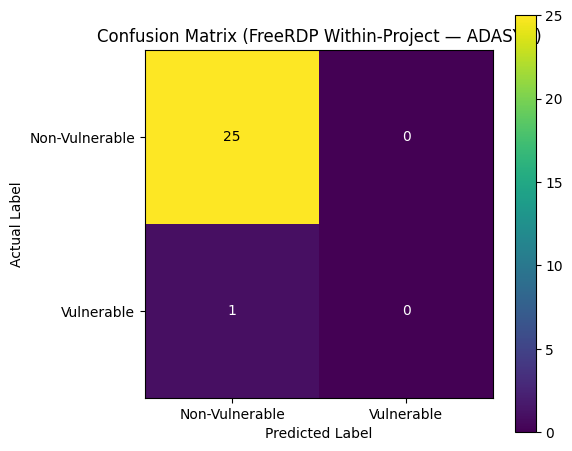

In [5]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on FreeRDP (train split) -> Test on FreeRDP (test split)
ADASYN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "FreeRDP"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/adasyn"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the ADASYN-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — ADASYN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | ADASYN ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to FreeRDP only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply ADASYN on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying ADASYN...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before ADASYN — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    # ADASYN may produce slightly variable sample counts across runs
    # due to its density-based adaptive sampling strategy
    adasyn = ADASYN(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # ADASYN can fail when minority class is extremely small
        # (fewer samples than n_neighbors). Fall back with n_neighbors=1.
        print(f"      ADASYN default failed ({e}). Retrying with n_neighbors=1...")
        adasyn = ADASYN(random_state=SEED, n_neighbors=1)
        train_emb_res, train_lbl_res = adasyn.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  ADASYN — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-ADASYN): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "adasyn_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_adasyn" : int(len(train_lbl)),
        "n_train_after_adasyn"  : int(len(train_lbl_res)),
        "n_vuln_before_adasyn"  : n_pos_before,
        "n_benign_before_adasyn": n_neg_before,
        "n_vuln_after_adasyn"   : n_pos_after,
        "n_benign_after_adasyn" : n_neg_after,
        "n_test_samples"        : int(len(test_lbl)),
        "n_vuln_test"           : int(test_lbl.sum()),
        "class_weights"         : class_weights,
        "accuracy"              : round(float(accuracy),  4),
        "precision"             : round(float(precision), 4),
        "recall"                : round(float(recall),    4),
        "f1"                    : round(float(f1),        4),
        "auc"                   : round(float(auc),       4),
        "g_mean"                : round(float(g_mean),    4),
        "pf"                    : round(float(pf),        4),
        "confusion_matrix"      : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"adasyn_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_adasyn_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()